# 09 — Feature interpretability (proposal 3.2, 3.3.2)

"Logistic regression coefficient weights and class-level feature means are
further examined to profile each LLM's stylistic tendencies and identify the
signals most strongly associated with each source class."

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))  # so `import src...` works from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, data, features, modeling, viz
from src.utils import set_seed, save_fig
set_seed()  # fix all RNGs -- reproducibility

Coefficients are examined **per feature block** (TF-IDF alone, style alone)
rather than pulled out of the combined Exp6 model. Two reasons: (1) it's much
cheaper -- single-block fits are seconds-to-minutes vs. Exp6's ~35-40 min --
and (2) it's more honestly interpretable: in the combined model, L2
regularization spreads weight across correlated features from different
blocks in ways that are harder to read class-by-class. Per-block coefficients
answer the proposal's question directly -- "which lexical/stylometric/
linguistic signals are most associated with each class" -- without that
confound.

In [2]:
clean = data.load_or_build_clean(); splits = data.load_or_build_splits(clean)
y = clean[config.LABEL_COL].values
texts = clean['text']
ytr, yval = y[splits['train']], y[splits['val']]

## TF-IDF: top words per class

In [3]:
X_tfidf, vec = features.build_tfidf(texts.iloc[splits['train']], texts)
Xtr, Xval = X_tfidf[splits['train']], X_tfidf[splits['val']]

res_tfidf = modeling.train_and_evaluate('logreg', Xtr, ytr, Xval, yval, labels=list(config.CLASSES))
print('TF-IDF-only Macro-F1 (val):', res_tfidf.macro_f1)

TF-IDF-only Macro-F1 (val): 0.7415977426456036


In [4]:
vocab = vec.get_feature_names_out()
coef = res_tfidf.model.coef_   # shape (12, vocab_size)

top_words = {}
for i, cls in enumerate(res_tfidf.labels):
    order = np.argsort(coef[i])
    top_words[cls] = {
        'top_positive': list(vocab[order[-15:]][::-1]),
        'top_negative': list(vocab[order[:15]]),
    }

for cls, d in top_words.items():
    print(f"\n{cls}:")
    print("  + (pushes toward this class):", ', '.join(d['top_positive']))
    print("  - (pushes away from this class):", ', '.join(d['top_negative']))


human:
  + (pushes toward this class): various, the authors, authors, recently, this, this paper, leaving, crucial, as, overall, solace, however, any, during, with its
  - (pushes away from this class): said, is, was, the, and to, the novel, that is, here, people, degrees, which, and that, this is, approach to, we

chatgpt:
  + (pushes toward this class): degrees, instructions, an, this, novel written, edit, we, as, and, by, thanks, oh, ingredients, in, when
  - (pushes away from this class): paper, this paper, is set, we also, ve been, br, directions, however, enjoy, significant, also, early life, is based, ve, abstract

gpt4:
  + (pushes toward this class): here is, abstract, the, and, it, as, here, an, to, 2022, the movie, is recipe, plot summary, despite, body of
  - (pushes away from this class): also, ve, ve been, is also, one of, enjoy your, early life, novel is, said, novel by, pepper to, is based, during, outperforms, set in

gpt3:
  + (pushes toward this class): com, here th

## Stylometric + Biber: coefficients per class

In [5]:
sty = features.build_stylometric(texts)
sty_scaled, _ = features.scale_dense(sty.values, splits['train'])
bib = features.build_biber(texts)
bib_scaled, _ = features.scale_dense(bib.values, splits['train'])

style_blocks = {'stylometric': sty_scaled, 'biber': bib_scaled, 'length': clean[['log_token_count']].values}
X_style = features.assemble(style_blocks, ['stylometric', 'biber'], splits['train'])
feature_names = list(sty.columns) + list(bib.columns) + ['log_token_count']

Xtr_s, Xval_s = X_style[splits['train']], X_style[splits['val']]
res_style = modeling.train_and_evaluate('logreg', Xtr_s, ytr, Xval_s, yval, labels=list(config.CLASSES))
print('Style-only Macro-F1 (val):', res_style.macro_f1)

Style-only Macro-F1 (val): 0.3664556182854605


,avg_sentence_len,avg_word_len,ttr,mtld,comma_ratio,period_ratio,question_ratio,exclam_ratio,pos_noun,pos_propn,...,pos_cconj,pos_sconj,pos_part,pos_intj,pos_num,modal_ratio,passive_ratio,nominalisation_ratio,discourse_marker_ratio,log_token_count
human,-0.50,0.77,-0.07,1.11,0.49,0.52,0.31,0.13,0.14,-0.22,...,0.45,0.04,-0.06,-0.13,-0.54,0.14,-0.37,-0.01,0.16,0.25
chatgpt,0.23,-0.28,0.86,0.11,-0.11,-0.32,0.25,0.08,-0.19,0.13,...,-0.13,0.25,-0.09,0.04,0.23,0.02,0.06,0.06,0.00,0.42
gpt4,0.13,-0.18,1.43,-0.25,-0.04,-0.23,-0.05,-0.03,0.03,0.14,...,0.05,0.14,0.02,0.03,0.22,0.12,0.02,0.03,0.01,0.09
gpt3,0.26,-0.05,-2.98,-0.91,-0.13,0.21,-0.02,-0.05,0.22,0.41,...,-0.22,-0.09,0.12,0.13,0.26,-0.17,0.34,-0.09,-0.25,-1.06
gpt2,0.06,-0.72,1.92,-1.00,-0.48,0.02,-0.46,-0.25,0.04,0.28,...,-0.37,-0.17,-0.08,-0.13,0.13,0.03,0.20,0.05,-0.11,-0.67
llama-chat,-1.00,0.93,-0.07,0.92,0.50,0.54,0.30,0.09,0.13,-0.30,...,-0.19,0.01,0.15,-0.12,-0.57,-0.21,-0.32,-0.12,-0.03,0.50
mistral,0.21,-0.81,0.45,1.06,-0.60,-0.48,0.05,0.05,0.20,0.52,...,-0.21,0.23,-0.18,0.05,0.19,0.19,0.10,-0.02,-0.06,0.50
mistral-chat,0.07,0.42,-0.49,0.77,0.41,-0.41,0.13,0.08,-0.02,-0.57,...,0.36,-0.15,0.21,0.21,0.28,0.01,-0.10,0.03,0.01,0.93
mpt,0.21,-0.14,-1.37,-1.00,-0.31,0.12,-0.09,-0.25,-0.34,-0.13,...,-0.31,-0.21,-0.05,0.00,-0.03,-0.15,0.26,0.06,-0.03,-0.01
mpt-chat,-0.10,0.12,0.60,-0.31,0.17,-0.28,-0.25,0.05,-0.12,-0.29,...,0.36,-0.02,-0.01,-0.11,0.07,0.07,-0.21,0.09,0.24,0.22


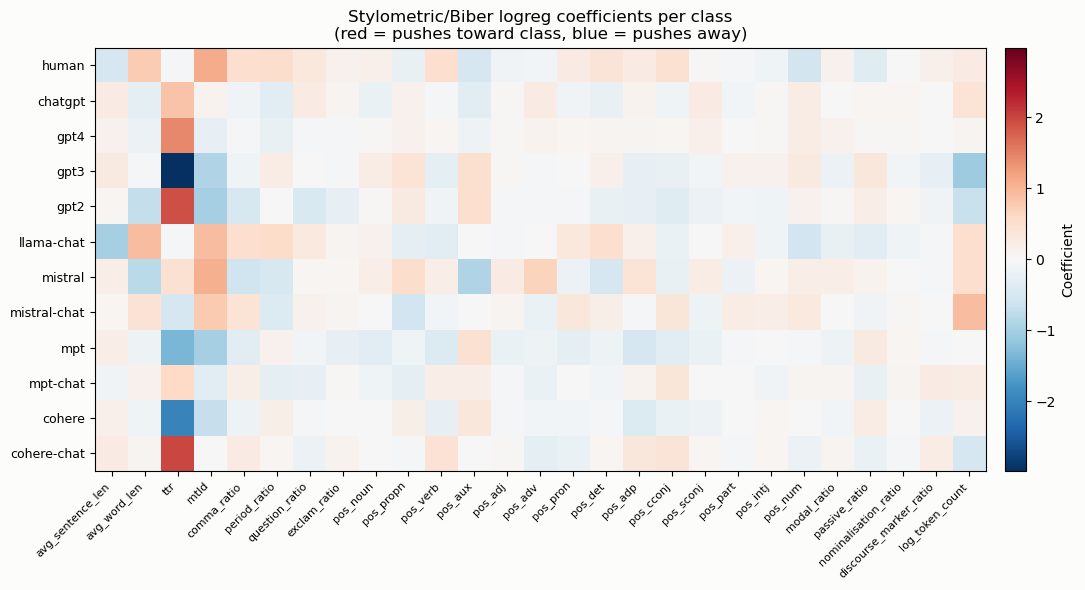

In [6]:
coef_s = res_style.model.coef_
style_coef_df = pd.DataFrame(coef_s, index=res_style.labels, columns=feature_names)

fig, ax = plt.subplots(figsize=(11, 6), facecolor=viz.SURFACE)
vmax = np.abs(style_coef_df.values).max()
im = ax.imshow(style_coef_df.values, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(style_coef_df.columns))); ax.set_xticklabels(style_coef_df.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(style_coef_df.index))); ax.set_yticklabels(style_coef_df.index, fontsize=9)
ax.set_title('Stylometric/Biber logreg coefficients per class\n(red = pushes toward class, blue = pushes away)')
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Coefficient')
fig.tight_layout()
save_fig(fig, 'style_coefficients_heatmap')
style_coef_df.round(2)

## Class-level feature means (raw units, no model needed)

In [7]:
raw = pd.concat([sty, bib], axis=1)
raw['model'] = y
class_means = raw.groupby('model').mean().reindex(config.CLASSES)
class_means.to_csv(config.ARTIFACTS / 'class_feature_means.csv')
class_means.round(3)

,avg_sentence_len,avg_word_len,ttr,mtld,comma_ratio,period_ratio,question_ratio,exclam_ratio,pos_noun,pos_propn,...,pos_adp,pos_cconj,pos_sconj,pos_part,pos_intj,pos_num,modal_ratio,passive_ratio,nominalisation_ratio,discourse_marker_ratio
model,,,,,,,,,,,,,,,,,,,,,
human,26.598,4.669,0.573,86.685,0.009,0.009,0.000,0.0,0.188,0.074,...,0.098,0.034,0.016,0.023,0.001,0.022,0.008,0.015,0.016,0.002
chatgpt,19.023,5.015,0.564,81.663,0.011,0.009,0.000,0.0,0.220,0.044,...,0.098,0.040,0.014,0.022,0.000,0.011,0.007,0.013,0.027,0.003
gpt4,18.120,4.934,0.550,75.699,0.013,0.010,0.000,0.0,0.217,0.049,...,0.099,0.033,0.013,0.022,0.000,0.012,0.006,0.014,0.024,0.002
gpt3,22.345,4.527,0.578,55.094,0.009,0.011,0.000,0.0,0.181,0.072,...,0.090,0.032,0.013,0.022,0.000,0.026,0.008,0.022,0.014,0.001
gpt2,77.068,4.313,0.090,18.420,0.007,0.010,0.000,0.0,0.199,0.088,...,0.091,0.018,0.010,0.023,0.000,0.032,0.003,0.031,0.011,0.000
llama-chat,26.909,4.780,0.518,71.552,0.013,0.008,0.000,0.0,0.204,0.042,...,0.093,0.041,0.014,0.025,0.001,0.016,0.008,0.016,0.022,0.002
mistral,52.417,4.419,0.223,27.447,0.008,0.010,0.000,0.0,0.182,0.074,...,0.082,0.024,0.011,0.022,0.000,0.031,0.005,0.028,0.013,0.000
mistral-chat,23.493,4.760,0.534,62.632,0.011,0.009,0.000,0.0,0.203,0.048,...,0.096,0.041,0.014,0.023,0.000,0.017,0.008,0.017,0.021,0.003
mpt,47.597,4.372,0.178,27.339,0.008,0.010,0.000,0.0,0.184,0.079,...,0.085,0.025,0.011,0.023,0.000,0.027,0.006,0.027,0.013,0.000


PosixPath('/Users/xinye/Desktop/module 3/5 nautral language proccesing/syndicate asm/llm-source-attribution/figures/class_feature_means_heatmap.png')

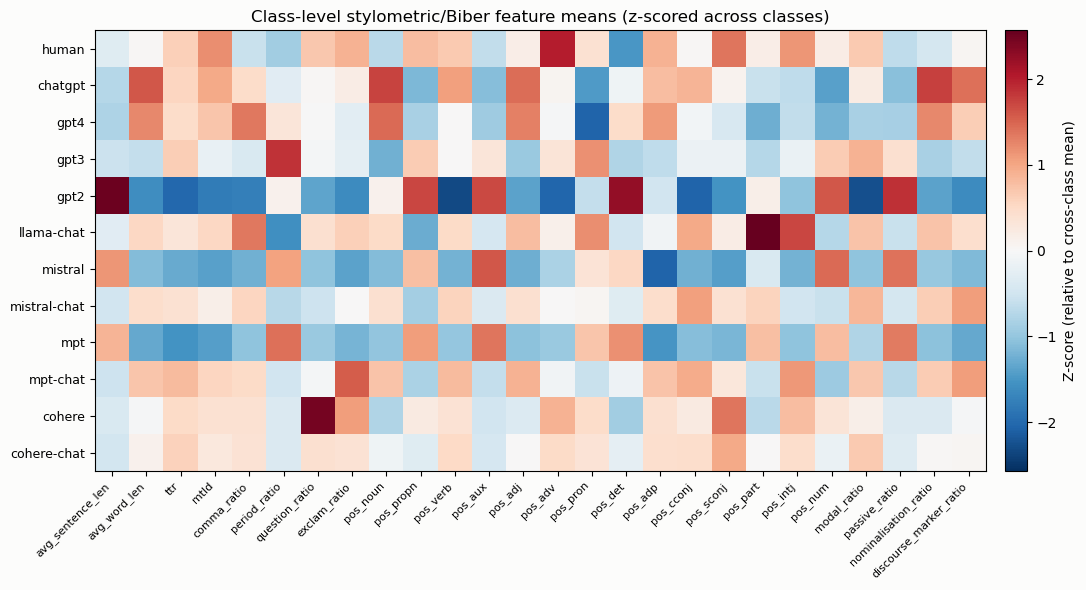

In [8]:
# z-score across classes per feature -- raw units differ wildly in scale
# (avg_sentence_len is in words, ttr is a 0-1 ratio), so z-scoring is what
# makes them visually comparable in one heatmap.
z = (class_means - class_means.mean()) / class_means.std()

fig, ax = plt.subplots(figsize=(11, 6), facecolor=viz.SURFACE)
vmax = np.abs(z.values).max()
im = ax.imshow(z.values, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(z.columns))); ax.set_xticklabels(z.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(z.index))); ax.set_yticklabels(z.index, fontsize=9)
ax.set_title('Class-level stylometric/Biber feature means (z-scored across classes)')
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Z-score (relative to cross-class mean)')
fig.tight_layout()
save_fig(fig, 'class_feature_means_heatmap')

### Conclusion

**This notebook finally explains the *mechanism* behind the base-model outlier
cluster that 05/06/07 kept finding but couldn't fully explain.** gpt2/mistral/mpt
don't just cluster apart abstractly — they have a concrete, measurable stylometric
signature that's completely different from every other class:

| | avg_sentence_len | ttr | passive_ratio | modal_ratio | discourse_marker_ratio |
|---|---|---|---|---|---|
| **gpt2** | **77.1** | **0.090** | 0.031 | 0.003 | 0.000 |
| **mistral** | **52.4** | **0.223** | 0.028 | 0.005 | 0.000 |
| **mpt** | **47.6** | **0.178** | 0.027 | 0.006 | 0.000 |
| everyone else (range) | 18–27 | 0.52–0.61 | 0.013–0.022 | 0.006–0.008 | 0.001–0.003 |

Sentences 2–4× longer, lexical diversity 2.5–6× lower, more passive voice, fewer
modal verbs, essentially zero discourse markers. That's the signature of
**non-instruction-tuned base models rambling without natural stopping points and
repeating themselves** — exactly what you'd expect from generation that never went
through RLHF/chat-formatting training to produce clearly-segmented, hedged,
discourse-organized text. This is a mechanistic, stylometric confirmation of the
"base vs. chat-tuned" split that drove the confusion-pattern clustering (05) and
the embedding clustering (06) — those weren't just abstract geometric findings,
here's the actual measurable writing-style difference behind them.

**A few more individually striking class signatures** (visible as the extreme
cells in the z-scored heatmap): **human** writing is distinctly high in `pos_adv`
(adverb use) relative to every LLM; **cohere** asks questions
(`question_ratio`) far more than anything else in the dataset; **llama-chat**
stands out on `pos_part`/`pos_intj` (particles/interjections).

**The TF-IDF top words are a direct, literal illustration of the proposal's own
caveat that lexical features "may partly reflect prompt wording or topic
overlap" rather than pure style.** Several classes' top coefficients are
recognizably *domain* artifacts, not stylistic ones: `mistral-chat`'s top words
include "sure here", "hey fellow", "redditors" (Reddit-domain chatbot-opener
phrasing); `mpt`'s include "the recipe", "recipe is", "white sugar"
(recipe-domain); `gpt4`'s include "abstract", "plot summary" (abstracts/books
domain). This is worth quoting directly in the report's RQ1 discussion — it's
concrete evidence for *why* TF-IDF's dominance in `03_ablation` should be read
with the prompt-leakage caveat rather than as pure evidence of stronger lexical
"style."